In [102]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

from aml_tools_2025 import aml_data_read_2025, aml_remove_nan, aml_oxygen_correction

fname = '/Users/ej/Desktop/Applied Ocean Observation Technologies/AML/AML Data 2025/aml_log_2025-06-11_04-53-37.aml'

h, V, D = aml_data_read_2025(fname)
print("Number of variables:", len(D))


# List all variables
for i, d in enumerate(D):
    print(i, d['name'])

Number of variables: 22
0 Time
1 Vbat
2 Cond
3 ADC
4 TempCT
5 ADC
6 Pressure
7 ADC
8 DO
9 TempDO
10 DOM
11 ADC
12 Chloro-blue
13 ADC
14 Turbidity
15 ADC
16 analog
17 ADC
18 Salinity
19 Density
20 CalcSV
21 Depth


In [103]:
import os
all_files = [f for f in os.listdir('AML Data 2025') if f.endswith('.aml')]


valid_files = []

for f in all_files:
    
    fname = os.path.join('AML Data 2025', f)
    h, V, D = aml_data_read_2025(fname)
    
    if len(D[4]['dat']) > 100:   # ✅ threshold
        valid_files.append(f)
    else:
        print("Skipping:", f)

Skipping: aml_log_2025-06-11_04-59-04.aml


In [104]:
# =========================
# SELECT VARIABLES
# =========================
idepth = 21
itempCT = 4
idox = 8
isalt   = 18
ichla   = 12

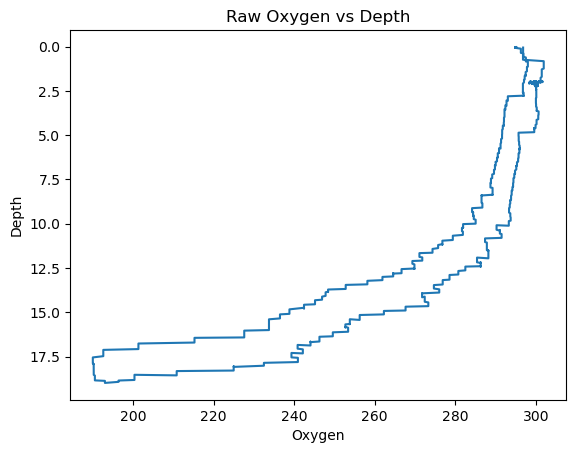

In [105]:

import matplotlib.pyplot as plt

plt.figure()
plt.plot(D[idox]['dat'], D[idepth]['dat'])
plt.gca().invert_yaxis()

plt.xlabel("Oxygen")
plt.ylabel("Depth")
plt.title("Raw Oxygen vs Depth")

plt.show()

In [106]:
from scipy.ndimage import uniform_filter1d
import numpy as np

In [110]:
from aml_tools import aml_remove_nan

D = aml_remove_nan(D, idepth)

In [111]:
print(len(D[idepth]['dat']))

2629


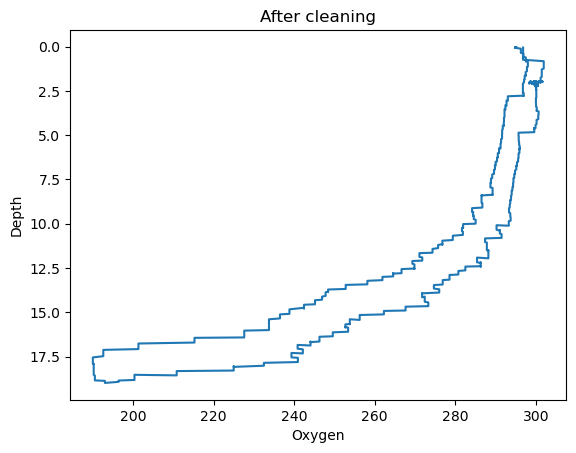

In [112]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(D[idox]['dat'], D[idepth]['dat'])

plt.gca().invert_yaxis()
plt.xlabel("Oxygen")
plt.ylabel("Depth")

plt.title("After cleaning")

plt.show()

In [113]:
from aml_tools import aml_oxygen_correction
#D = aml_oxygen_correction(D, idox, itempDO, ipress, isalt, idens)

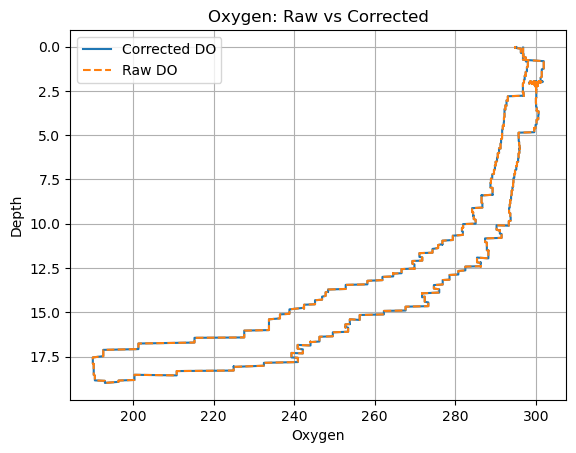

In [114]:
import matplotlib.pyplot as plt

plt.figure()

# corrected
plt.plot(D[idox]['dat'], D[idepth]['dat'], label='Corrected DO')

# original
plt.plot(D[idox]['dat'], D[idepth]['dat'], '--', label='Raw DO')

plt.gca().invert_yaxis()

plt.xlabel("Oxygen")
plt.ylabel("Depth")
plt.title("Oxygen: Raw vs Corrected")

plt.legend()
plt.grid()

plt.show()

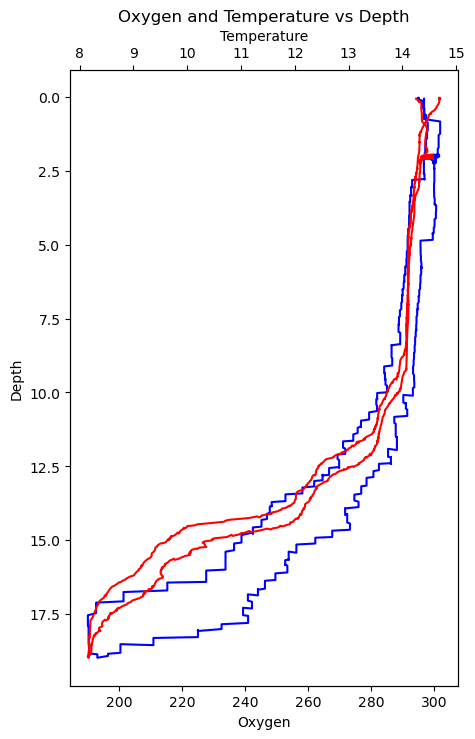

In [115]:
fig, ax1 = plt.subplots(figsize=(5, 8))

# Oxygen (left axis)
ax1.plot(D[idox]['dat'], D[idepth]['dat'], 'b-', label='Oxygen')
ax1.set_xlabel('Oxygen')
ax1.set_ylabel('Depth')
ax1.invert_yaxis()

# Second axis for temperature
ax2 = ax1.twiny()
ax2.plot(D[itempCT]['dat'], D[idepth]['dat'], 'r-', label='Temperature')
ax2.set_xlabel('Temperature')

plt.title("Oxygen and Temperature vs Depth")

plt.show()

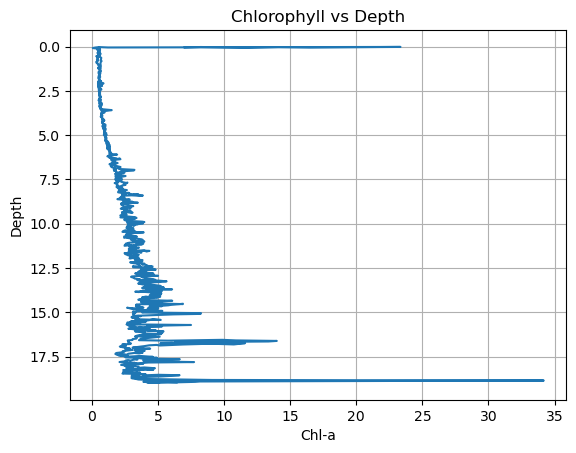

In [116]:
plt.figure()

plt.plot(D[ichla]['dat'], D[idepth]['dat'])
plt.gca().invert_yaxis()

plt.xlabel("Chl-a")
plt.ylabel("Depth")
plt.title("Chlorophyll vs Depth")

plt.grid()
plt.show()

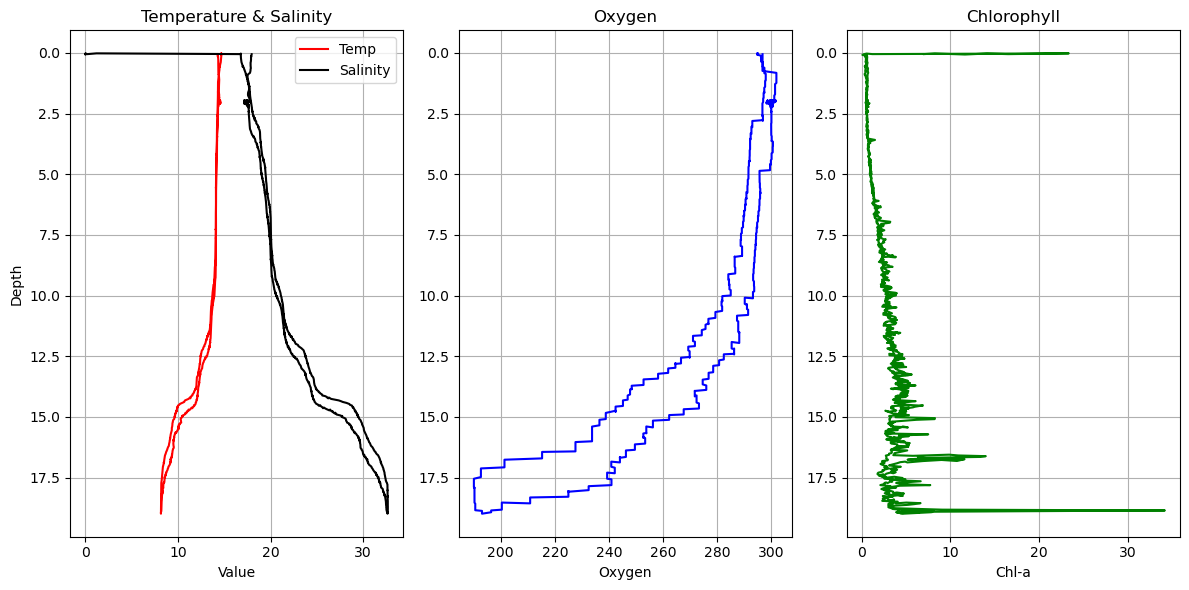

In [117]:
plt.figure(figsize=(12, 6))

# -------- Panel 1: Temperature + Salinity --------
plt.subplot(1, 3, 1)

plt.plot(D[itempCT]['dat'], D[idepth]['dat'], 'r-', label='Temp')
plt.plot(D[isalt]['dat'], D[idepth]['dat'], 'k-', label='Salinity')

plt.gca().invert_yaxis()
plt.xlabel('Value')
plt.ylabel('Depth')
plt.title('Temperature & Salinity')

plt.legend()
plt.grid()


# -------- Panel 2: Oxygen --------
plt.subplot(1, 3, 2)

plt.plot(D[idox]['dat'], D[idepth]['dat'], 'b-')

plt.gca().invert_yaxis()
plt.xlabel('Oxygen')
plt.title('Oxygen')

plt.grid()


# -------- Panel 3: Chlorophyll --------
plt.subplot(1, 3, 3)

plt.plot(D[ichla]['dat'], D[idepth]['dat'], 'g-')

plt.gca().invert_yaxis()
plt.xlabel('Chl-a')
plt.title('Chlorophyll')

plt.grid()


plt.tight_layout()
plt.show()

In [118]:
main_files = valid_files

In [146]:
import numpy as np
from scipy.ndimage import uniform_filter1d

def process_ctd_2025(fname):

    h, V, D = aml_data_read_2025(fname)

    ipress  = 6
    itempCT = 4
    isalt   = 18
    ichla   = 12
    idox    = 8

    depth = D[ipress]['dat'] - np.nanmin(D[ipress]['dat'])

    temp = D[itempCT]['dat']
    salt = D[isalt]['dat']
    chl  = D[ichla]['dat']
    do   = D[idox]['dat']

    # ✅ STEP 1: remove nan
    valid = np.isfinite(depth)
    depth, temp, salt, chl, do = depth[valid], temp[valid], salt[valid], chl[valid], do[valid]

    # ✅ STEP 2: remove surface (THIS is the key fix)
    valid = depth > 2.0
    depth, temp, salt, chl, do = depth[valid], temp[valid], salt[valid], chl[valid], do[valid]

    # remove unrealistic oxygen values
    do = np.where((do > 100) & (do < 400), do, np.nan)


    # ✅ STEP 3: remove extreme values (axis fix)
    temp = np.clip(temp, 0, 30)
    salt = np.clip(salt, 0, 40)
    chl  = np.clip(chl, 0, 20)

    # ✅ STEP 4: sort
    idx = np.argsort(depth)

    return {
        'depth': depth[idx],
        'temp': temp[idx],
        'salt': salt[idx],
        'chl':  chl[idx],
        'do':   do[idx]
    }

In [147]:
results = []

for f in valid_files:   # ✅ use filtered files
    
    fname = os.path.join('AML Data 2025', f)
    
    profile = process_ctd_2025(fname)
    
    depth = profile['depth']
    temp  = profile['temp']
    chl   = profile['chl']
    
    # --- transition depth (from temperature gradient)
    # ignore very shallow depths (<1 m)
    valid = depth > 1.0
    dT = np.gradient(temp)
    transition_depth = depth[valid][np.argmax(np.abs(dT[valid]))]

   # smooth chlorophyll
    chl_smooth = np.convolve(chl, np.ones(20)/20, mode='same')

    # ✅ ignore surface + bottom noise
    valid = (depth > 2.0) & (depth < np.nanmax(depth) - 1)

    # ✅ compute chl max only in valid region
    chl_depth = depth[valid][np.argmax(chl_smooth[valid])]
    
    results.append({
        'file': f,
        'transition_depth': transition_depth,
        'chl_max_depth': chl_depth
    })

In [148]:
import pandas as pd
from datetime import datetime   # ✅ ADD THIS

days = []

for f in results:
    date_str = f['file'].split('_')[2]
    date_obj = datetime.strptime(date_str, "%Y-%m-%d")
    days.append(date_obj.strftime('%A'))

df = pd.DataFrame(results)
df['day'] = days

print(df)

                               file  transition_depth  chl_max_depth  \
0   aml_log_2025-06-11_05-16-11.aml           7.54582        8.56664   
1   aml_log_2025-06-12_09-56-49.aml          13.94422       14.34516   
2   aml_log_2025-06-12_05-11-15.aml           2.36417        7.05144   
3   aml_log_2025-06-11_06-51-22.aml          10.88386       12.37027   
4   aml_log_2025-06-13_08-51-17.aml          13.00751       13.39359   
5   aml_log_2025-06-12_10-57-12.aml          12.72477       14.37684   
6   aml_log_2025-06-12_11-41-11.aml           2.65610        8.15757   
7   aml_log_2025-06-11_04-53-37.aml          12.73877       11.26331   
8   aml_log_2025-06-11_05-47-21.aml           8.79166        9.10905   
9   aml_log_2025-06-13_05-00-39.aml          11.76676       12.07997   
10  aml_log_2025-06-13_07-20-37.aml           9.91509       11.10208   
11  aml_log_2025-06-11_11-10-27.aml          12.78635       12.01391   
12  aml_log_2025-06-12_05-28-17.aml          11.99877       10.3

In [149]:
df['difference'] = df['chl_max_depth'] - df['transition_depth']
print(df[['transition_depth', 'chl_max_depth', 'difference']])

    transition_depth  chl_max_depth  difference
0            7.54582        8.56664     1.02082
1           13.94422       14.34516     0.40094
2            2.36417        7.05144     4.68727
3           10.88386       12.37027     1.48641
4           13.00751       13.39359     0.38608
5           12.72477       14.37684     1.65207
6            2.65610        8.15757     5.50147
7           12.73877       11.26331    -1.47546
8            8.79166        9.10905     0.31739
9           11.76676       12.07997     0.31321
10           9.91509       11.10208     1.18699
11          12.78635       12.01391    -0.77244
12          11.99877       10.31660    -1.68217
13          11.70438       11.83254     0.12816
14           2.02130       18.16214    16.14084
15           6.87473        7.69565     0.82092
16           2.00022        2.37483     0.37461
17          14.63219       16.84316     2.21097


In [150]:
print(np.nanmin(D['do']), np.nanmax(D['do']))

190.04 301.62


In [151]:
all_profiles_2025 = []

for f in valid_files:
    
    fname = os.path.join('AML Data 2025', f)
    
    profile = process_ctd_2025(fname)
    
    all_profiles_2025.append(profile)

In [152]:
for p in all_profiles_2025:
    depth = p['depth']
    temp  = p['temp']

In [153]:
import numpy as np
import matplotlib.pyplot as plt

depth_bins = np.arange(0, 20, 0.5)

depth_centers = []

mean_temp = []
mean_salt = []
mean_chl  = []

In [154]:
for i in range(len(depth_bins)-1):
    
    zmin = depth_bins[i]
    zmax = depth_bins[i+1]
    
    temp_vals = []
    salt_vals = []
    chl_vals  = []
    
    for p in all_profiles_2025:
        
        depth = p['depth']
        
        mask = (depth >= zmin) & (depth < zmax)
        
        temp_vals.extend(p['temp'][mask])
        salt_vals.extend(p['salt'][mask])
        
        # ✅ clip chl to remove spikes (important!)
        chl_vals.extend(np.clip(p['chl'][mask], 0, 5))
    
    if len(temp_vals) > 0:
        depth_centers.append((zmin + zmax)/2)
        mean_temp.append(np.mean(temp_vals))
        mean_salt.append(np.mean(salt_vals))
        mean_chl.append(np.mean(chl_vals))

In [155]:
p['temp'] = np.clip(p['temp'], -5, 30)
p['salt'] = np.clip(p['salt'], 0, 40)
p['chl']  = np.clip(p['chl'], 0, 50)

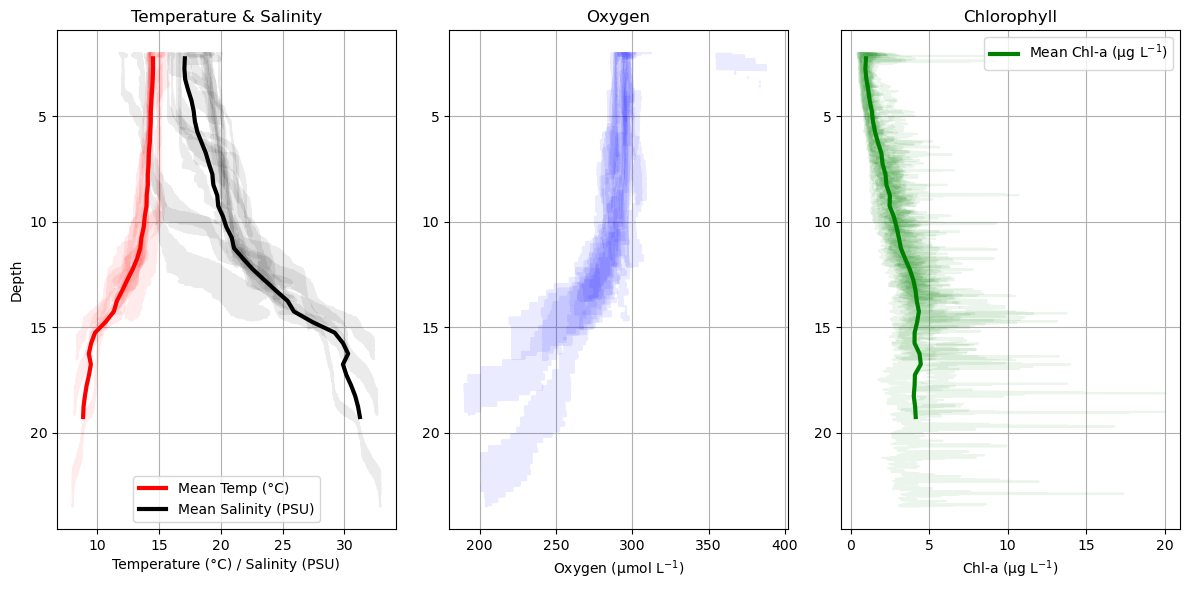

In [157]:
plt.figure(figsize=(12, 6))

# -------- Panel 1: Temperature + Salinity --------
plt.subplot(1, 3, 1)

for p in all_profiles_2025:
    plt.plot(p['temp'], p['depth'], 'r-', alpha=0.08)
    plt.plot(p['salt'], p['depth'], 'k-', alpha=0.08)

plt.plot(mean_temp, depth_centers, 'r-', linewidth=3, label='Mean Temp (°C)')
plt.plot(mean_salt, depth_centers, 'k-', linewidth=3, label='Mean Salinity (PSU)')

plt.gca().invert_yaxis()
plt.xlabel('Temperature (°C) / Salinity (PSU)')
plt.ylabel('Depth')
plt.title('Temperature & Salinity')

plt.legend()
plt.grid()


# -------- Panel 2: Oxygen --------
plt.subplot(1, 3, 2)

for p in all_profiles_2025:
    plt.plot(p['do'], p['depth'], 'b-', alpha=0.08)

plt.gca().invert_yaxis()
plt.xlabel('Oxygen (µmol L$^{-1}$)')
plt.title('Oxygen')

plt.grid()


# -------- Panel 3: Chlorophyll --------
plt.subplot(1, 3, 3)

for p in all_profiles_2025:
    plt.plot(p['chl'], p['depth'], 'g-', alpha=0.08)

plt.plot(mean_chl, depth_centers, 'g-', linewidth=3, label='Mean Chl-a (µg L$^{-1}$)')

plt.gca().invert_yaxis()
plt.xlabel('Chl-a (µg L$^{-1}$)')
plt.title('Chlorophyll')

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [130]:

print(type(all_profiles_2025[0]))
print(all_profiles_2025[0].keys())


<class 'dict'>
dict_keys(['depth', 'temp', 'salt', 'chl', 'do'])
